Primary Biliary Cholangitis Data from Mayo Clinical Trial conducted between 1974 and 1984. A total of 424 PBC patients, referred to Mayo Clinic during that ten-year interval, 
met eligibility criteria for the randomized placebo controlled trial of the drug D-penicillamine. 
The first 312 cases in the data set participated in the randomized trial and contain largely complete data. 
The additional 112 cases did not participate in the clinical trial, but consented to have basic measurements recorded and to be followed for survival. 
Six of those cases were lost to follow-up shortly after diagnosis, so the data here are on an additional 106 cases as well as the 312 randomized participants.

Primmary Biliary Cholangitis (PBC) is an autoimmune disease which leads to the destruction of small bile ducts in the the liver. 

Full documentation: [PBC dataset (Rdatasets)](https://vincentarelbundock.github.io/Rdatasets/doc/survival/pbc.html)

In [2]:
#Loading pacakges and Biostatistics/Clinical Trials: Mayo Clinic PBC trial data 
import pandas as pd
import matplotlib.pyplot as plt

%run ../scripts/fetch_data.py
pbc.shape

(418, 21)

In [3]:
#Exploratory data analysis 
pbc.head()
pbc.info()
pbc.describe()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  418 non-null    int64  
 1   id        418 non-null    int64  
 2   time      418 non-null    int64  
 3   status    418 non-null    int64  
 4   trt       312 non-null    float64
 5   age       418 non-null    float64
 6   sex       418 non-null    str    
 7   ascites   312 non-null    float64
 8   hepato    312 non-null    float64
 9   spiders   312 non-null    float64
 10  edema     418 non-null    float64
 11  bili      418 non-null    float64
 12  chol      284 non-null    float64
 13  albumin   418 non-null    float64
 14  copper    310 non-null    float64
 15  alk.phos  312 non-null    float64
 16  ast       312 non-null    float64
 17  trig      282 non-null    float64
 18  platelet  407 non-null    float64
 19  protime   416 non-null    float64
 20  stage     412 non-null    float64
dtypes: f

,rownames,id,time,status,trt,age,ascites,hepato,spiders,edema,bili,chol,albumin,copper,alk.phos,ast,trig,platelet,protime,stage
count,418.000000,418.000000,418.000000,418.000000,312.000000,418.000000,312.000000,312.000000,312.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,209.500000,1917.782297,0.830144,1.493590,50.741551,0.076923,0.512821,0.288462,0.100478,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,120.810458,1104.672992,0.955785,0.500762,10.447214,0.266897,0.500639,0.453775,0.253417,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,1.000000,41.000000,0.000000,1.000000,26.277892,0.000000,0.000000,0.000000,0.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,105.250000,1092.750000,0.000000,1.000000,42.832307,0.000000,0.000000,0.000000,0.000000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,209.500000,1730.000000,0.000000,1.000000,51.000684,0.000000,1.000000,0.000000,0.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,313.750000,2613.500000,2.000000,2.000000,58.240931,0.000000,1.000000,1.000000,0.000000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,418.000000,4795.000000,2.000000,2.000000,78.439425,1.000000,1.000000,1.000000,1.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


Analysis Questions: 
1. How does bilirubin and albumin vary by histologic stage? 
2. Can either bilirubin or albumin be used as a prognostic biomarker? 


In [4]:
#Question 1
q1 = pbc[["id", "stage", "bili", "albumin"]]
q1.head()
q1.info()



<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       418 non-null    int64  
 1   stage    412 non-null    float64
 2   bili     418 non-null    float64
 3   albumin  418 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 13.2 KB


In [5]:
q1 = q1.dropna(subset=["stage"])
q1.shape

(412, 4)

In [11]:
q1.groupby("stage")[["bili", "albumin"]].agg(["median", "mean", "count"])

bili                 albumin                
      median      mean count  median      mean count
stage                                               
1.0     0.80  1.361905    21   3.770  3.705238    21
2.0     0.95  2.453261    92   3.615  3.607065    92
3.0     1.30  2.825806   155   3.610  3.592387   155
4.0     2.55  4.427083   144   3.340  3.302431   144

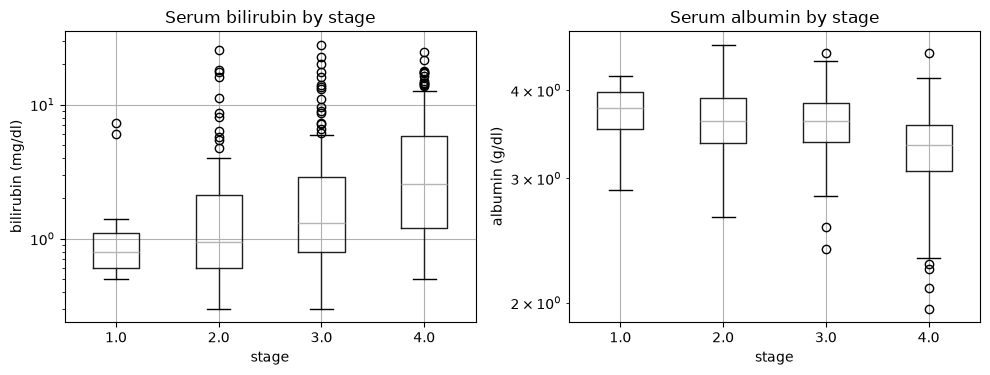

In [15]:
#Creating a Boxplot comparing bilirubin and albumin by stage
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

q1.boxplot(column="bili", by="stage", ax=axes[0])
axes[0].set_title("Serum bilirubin by stage")
axes[0].set_ylabel("bilirubin (mg/dl)")
axes[0].set_yscale("log")

q1.boxplot(column="albumin", by="stage", ax=axes[1])
axes[1].set_title("Serum albumin by stage")
axes[1].set_ylabel("albumin (g/dl)")
axes[1].set_yscale("log")

fig.suptitle("")
plt.tight_layout()
plt.show()

In [19]:
#Question 2


q2 = pbc[["id", "status", "time", "bili", "albumin"]].copy()
q2["died"] = q2["status"] == 2

#Is bilirubin a prognostic biomarker?
q2["bili_group"] = pd.qcut(q2["bili"], q=4, labels=["Q1", "Q2", "Q3", "Q4"]) #split patients into bilirubin quartiles (equal-count bins, Q1 = lowest)

q2.groupby("bili_group", observed=True)["died"].mean() #proportion who died in each quartile

bili_group
Q1    0.146341
Q2    0.252632
Q3    0.459184
Q4    0.725490
Name: died, dtype: float64

In [20]:
#Is albumin a prognostic biomarker?

q2["alb_group"] = pd.qcut(q2["albumin"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
q2.groupby("alb_group", observed=True)["died"].mean()


alb_group
Q1    0.590476
Q2    0.400000
Q3    0.250000
Q4    0.298077
Name: died, dtype: float64

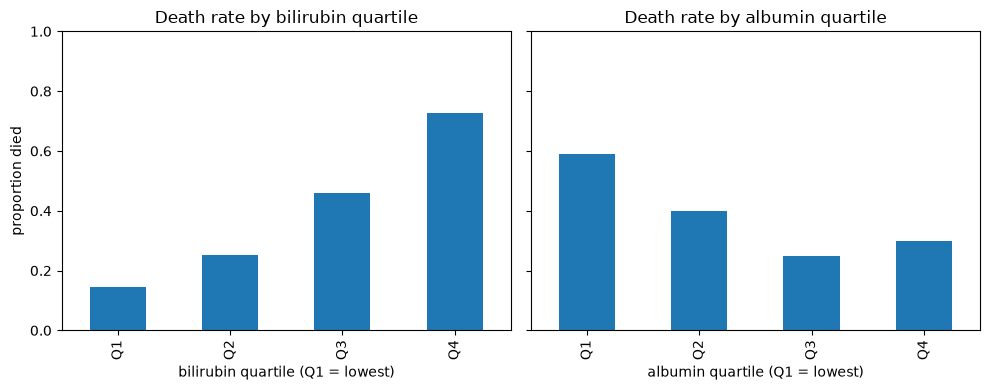

In [22]:
#plot
bili_rate = q2.groupby("bili_group", observed=True)["died"].mean()
alb_rate  = q2.groupby("alb_group", observed=True)["died"].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

bili_rate.plot(kind="bar", ax=axes[0])
axes[0].set_title("Death rate by bilirubin quartile")
axes[0].set_xlabel("bilirubin quartile (Q1 = lowest)")
axes[0].set_ylabel("proportion died")

alb_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Death rate by albumin quartile")
axes[1].set_xlabel("albumin quartile (Q1 = lowest)")

axes[0].set_ylim(0, 1)
plt.tight_layout()
plt.show()


Based on the analysis we see that Bilirubin slightly increase by PBC stage, while albumin stays realtively steady at each PBC stage.
Death Rate was determined by finding the status of those who have been declared dead, splitting bilirubinlalbumin into quartiles and then
finding the proportion of those who died in each quartile of bilirubin/albumin amounts. Based on the data we see that as bilirubin increases the rate of death increases, while the inverse is true albumin, with decline death rates as albumin increases. 
